In [2]:
import sys
import os
import time
import numpy as np
import logging
from scipy.spatial import procrustes
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr







# Add the repository root to sys.path
sys.path.append(os.path.abspath(".."))
from utils.config import load_config, Configuration

# Load configuration
config = load_config("../config.yaml")

# Define parameters and sets
sets = ["faceclass"]
subj = 1
mask_mode = "single"  # Mode used in naming (e.g., "single" or "averaged")

# Set initial directories for stan_data
config.directories.rdm_dir = "data/rdm/rdm_faceclass"
config.directories.mds_dir = "data/mds/mds_faceclass"
print("Initial RDM directory:", config.directories.rdm_dir)

# Loop over each dataset in 'sets'
for set_path in sets:
    print(f"\nComputing for {set_path} ...")
    time.sleep(1)
    
    # Update the directories for the current set
    config.directories.rdm_dir = f"data/rdm/rdm_{set_path}"
    config.directories.mds_dir = f"data/mds/mds_{set_path}"
    
    # Loop over all mask values (adjust range as needed)
    for mask_value in range(1, 9):
        # Iterate over the three hemisphere modes
        hemispheres = ["both", "lh", "rh"]
        for hemi in hemispheres:
            # Dictionary to hold the sample MDS matrices for the current hemisphere
            sample_mds = {}
            # Loop over sample numbers; adjust the samples as needed
            for sample in [0, 1, 2]:
                mds_path = os.path.join("..",
                                        config.directories.mds_dir,
                                        f"subj_{subj:02d}",
                                        f"subj_{subj:02d}",
                                        f"mask_{mask_value}_{mask_mode}_sample_{sample}_{hemi}_mds.npy")
                if os.path.exists(mds_path):
                    try:
                        sample_mds[sample] = np.load(mds_path)
                        logging.info(f"Loaded MDS file for mask {mask_value} ({hemi}) sample {sample} from: {mds_path}")
                    except Exception as e:
                        logging.warning(f"Error loading MDS file for mask {mask_value} ({hemi}) sample {sample}: {e}")
                else:
                    logging.warning(f"MDS file not found: {mds_path}")
            
            # Check if at least two sample files are available for this hemisphere before comparing
            if len(sample_mds) < 2:
                print(f"Mask {mask_value} ({hemi}): Not enough samples available for comparison. Skipping.")
                continue
            
            # Prepare lists for samples and names sorted by sample index
            sample_indices = sorted(sample_mds.keys())
            samples = [sample_mds[s] for s in sample_indices]
            sample_names = [f"sample_{s}" for s in sample_indices]
            
            # Perform pairwise comparisons using Procrustes analysis and Pearson correlations
            corrs = []
            n_samples = len(samples)
            for i in range(n_samples):
                for j in range(i + 1, n_samples):
                    mtx1, mtx2, disparity = procrustes(samples[i], samples[j])
                    # Compute pairwise distances on aligned matrices
                    dist1 = squareform(pdist(mtx1))
                    dist2 = squareform(pdist(mtx2))
                    # Compute Pearson correlation between the resulting distance matrices
                    r, p_value = pearsonr(dist1.ravel(), dist2.ravel())
                    corrs.append(r)
                    print(f"Mask {mask_value} ({hemi}): Comparing {sample_names[i]} vs {sample_names[j]}: r = {r:.3f} | disparity = {disparity:.3f}")
            
            if corrs:
                print(f"Mask {mask_value} ({hemi}): Mean correlation: {np.mean(corrs):.2f}\n")
            else:
                print(f"Mask {mask_value} ({hemi}): No valid comparisons.\n")


Initial RDM directory: data/rdm/rdm_faceclass

Computing for faceclass ...
Mask 1 (both): Comparing sample_0 vs sample_1: r = 0.074 | disparity = 0.981
Mask 1 (both): Comparing sample_0 vs sample_2: r = 0.139 | disparity = 0.935
Mask 1 (both): Comparing sample_1 vs sample_2: r = 0.089 | disparity = 0.974
Mask 1 (both): Mean correlation: 0.10

Mask 1 (lh): Comparing sample_0 vs sample_1: r = 0.102 | disparity = 0.955
Mask 1 (lh): Comparing sample_0 vs sample_2: r = 0.076 | disparity = 0.972
Mask 1 (lh): Comparing sample_1 vs sample_2: r = 0.081 | disparity = 0.975
Mask 1 (lh): Mean correlation: 0.09

Mask 1 (rh): Comparing sample_0 vs sample_1: r = 0.099 | disparity = 0.976
Mask 1 (rh): Comparing sample_0 vs sample_2: r = 0.128 | disparity = 0.971
Mask 1 (rh): Comparing sample_1 vs sample_2: r = 0.103 | disparity = 0.968
Mask 1 (rh): Mean correlation: 0.11

Mask 2 (both): Comparing sample_0 vs sample_1: r = 0.064 | disparity = 0.992
Mask 2 (both): Comparing sample_0 vs sample_2: r = 0.0

In [23]:
os.path.exists("../data/mds/mds_3_classes/subj_01/subj_01/mask_1_averaged_both_mds.npy")

True

In [3]:
import sys
import os
import time
import numpy as np
import logging
import pandas as pd
from scipy.spatial import procrustes
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr

# Add the repository root to sys.path to locate our configuration module
sys.path.append(os.path.abspath(".."))
from utils.config import load_config, Configuration

# Load configuration
config = load_config("../config.yaml")

# Define parameters
# sets = ["3classes"]
mask_mode = "single"  # Mode used in naming (e.g., "single" or "averaged")
subjects = range(1, 2)  # Subjects from 1 to 8
hemispheres = ["both", "lh", "rh"]

all_correlations_mds = []


# Initialize the results list to accumulate summary data across subjects, mask values, and hemisphere modes.
results = []

# Process each dataset
for set_path in sets:
    print(f"\nProcessing dataset: {set_path} ...")
    time.sleep(1)
    # Update the directories for the current set
    config.directories.rdm_dir = f"data/rdm/rdm_{set_path}"
    config.directories.mds_dir = f"data/mds/mds_{set_path}"
    
    # Loop over subjects
    for subj in subjects:
        print(f"\nProcessing subject: {subj:02d}")
        # Loop over each mask value (1 to 8)
        for mask_value in range(1, 9):
            # Loop through the three hemisphere modes
            for hemi in hemispheres:
                # Dictionary to hold the sample MDS matrices for the current combination
                sample_mds = {}
                # Loop over sample numbers 0, 1, 2
                for sample in [0, 1, 2]:
                    mds_path = os.path.join(
                        "..",
                        config.directories.mds_dir,
                        f"subj_{subj:02d}",
                        f"subj_{subj:02d}",
                        f"mask_{mask_value}_{mask_mode}_sample_{sample}_{hemi}_mds.npy"
                    )
                    if os.path.exists(mds_path):
                        try:
                            sample_mds[sample] = np.load(mds_path)
                            logging.info(f"Loaded MDS for subj {subj:02d}, mask {mask_value} ({hemi}) sample {sample}")
                        except Exception as e:
                            logging.warning(f"Error loading MDS for subj {subj:02d}, mask {mask_value} ({hemi}) sample {sample}: {e}")
                    else:
                        logging.warning(f"MDS file not found for subj {subj:02d}, mask {mask_value} ({hemi}) sample {sample}: {mds_path}")
                
                # Check if at least two samples are available before comparing.
                if len(sample_mds) < 2:
                    print(f"Subject {subj:02d} Mask {mask_value} ({hemi}): Not enough samples available. Skipping.")
                    continue

                # Sort the available samples by sample index to ensure consistent pair ordering
                sample_indices = sorted(sample_mds.keys())
                samples = [sample_mds[s] for s in sample_indices]
                
                # Perform pairwise comparisons using Procrustes analysis and Pearson correlations.
                correlations = []
                n_samples = len(samples)
                for i in range(n_samples):
                    for j in range(i + 1, n_samples):
                        try:
                            mtx1, mtx2, disparity = procrustes(samples[i], samples[j])
                        except Exception as e:
                            logging.warning(f"Error in procrustes for subj {subj:02d}, mask {mask_value} ({hemi}) samples {i} vs {j}: {e}")
                            continue
                        # Compute the pairwise distance matrices from the aligned matrices
                        dist1 = squareform(pdist(mtx1))
                        dist2 = squareform(pdist(mtx2))
                        try:
                            r, p_value = pearsonr(dist1.ravel(), dist2.ravel())
                            correlations.append(r)

                            if hemi == "both":
                                all_correlations_mds.append({
                                    "subject": subj,
                                    "mask_value": mask_value,
                                    "sample_pair": f"{sample_indices[i]}-{sample_indices[j]}",
                                    "correlation": r
                                })

                            print(f"Subject {subj:02d} Mask {mask_value} ({hemi}): Comparing sample_{sample_indices[i]} vs sample_{sample_indices[j]}: r = {r:.3f} | disparity = {disparity:.3f}")
                        except Exception as e:
                            logging.warning(f"Error computing pearsonr for subj {subj:02d}, mask {mask_value} ({hemi}) samples {i} vs {j}: {e}")
                            continue
                if correlations:
                    mean_corr = np.mean(correlations)
                    n_comparisons = len(correlations)
                    print(f"Subject {subj:02d} Mask {mask_value} ({hemi}): Mean correlation: {mean_corr:.2f} over {n_comparisons} comparisons.")
                    results.append({
                        "subject": subj,
                        "mask_value": mask_value,
                        "hemisphere": hemi,
                        "mean_correlation": mean_corr,
                        "n_comparisons": n_comparisons
                    })
                else:
                    print(f"Subject {subj:02d} Mask {mask_value} ({hemi}): No valid comparisons.")

# Create a DataFrame from the results list and save to an Excel file.
# df_results = pd.DataFrame(results)
# output_excel = "mds_procrustes_summary.xlsx"
# df_results.to_excel(output_excel, index=False)
# print(f"\nSummary results saved to {output_excel}")



Processing dataset: faceclass ...

Processing subject: 01
Subject 01 Mask 1 (both): Comparing sample_0 vs sample_1: r = 0.074 | disparity = 0.981
Subject 01 Mask 1 (both): Comparing sample_0 vs sample_2: r = 0.139 | disparity = 0.935
Subject 01 Mask 1 (both): Comparing sample_1 vs sample_2: r = 0.089 | disparity = 0.974
Subject 01 Mask 1 (both): Mean correlation: 0.10 over 3 comparisons.
Subject 01 Mask 1 (lh): Comparing sample_0 vs sample_1: r = 0.102 | disparity = 0.955
Subject 01 Mask 1 (lh): Comparing sample_0 vs sample_2: r = 0.076 | disparity = 0.972
Subject 01 Mask 1 (lh): Comparing sample_1 vs sample_2: r = 0.081 | disparity = 0.975
Subject 01 Mask 1 (lh): Mean correlation: 0.09 over 3 comparisons.
Subject 01 Mask 1 (rh): Comparing sample_0 vs sample_1: r = 0.099 | disparity = 0.976
Subject 01 Mask 1 (rh): Comparing sample_0 vs sample_2: r = 0.128 | disparity = 0.971
Subject 01 Mask 1 (rh): Comparing sample_1 vs sample_2: r = 0.103 | disparity = 0.968
Subject 01 Mask 1 (rh): M

/tmp/ipykernel_74523/757136148.py:9: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


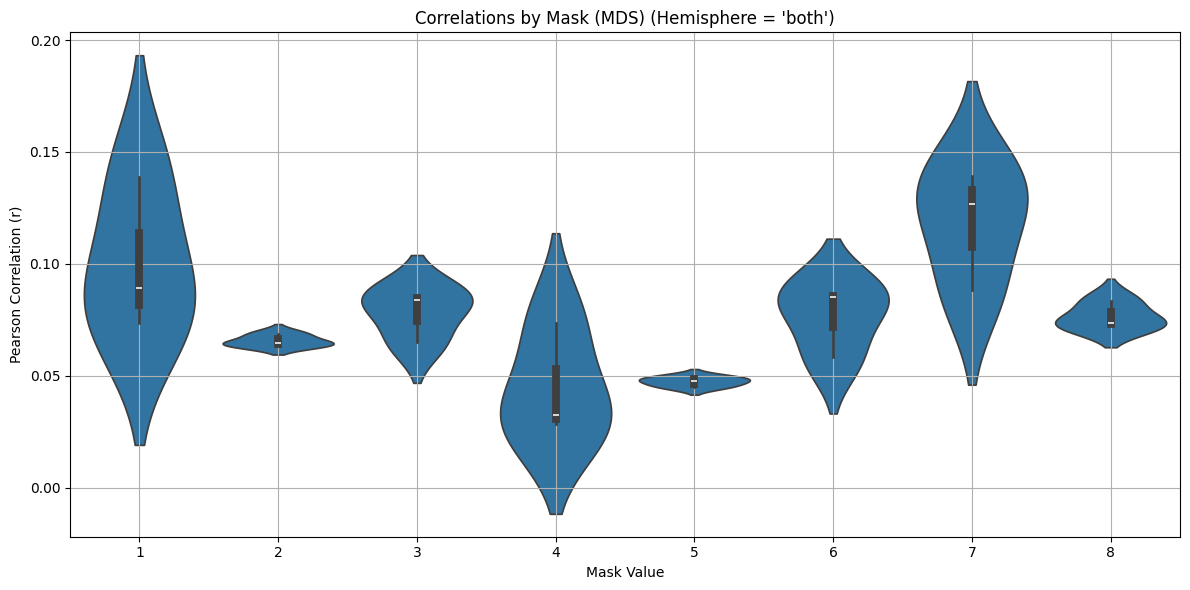

In [4]:
# Visualisierung: Violinplot der rohen Korrelationen pro Maske
import matplotlib.pyplot as plt
import seaborn as sns

# In DataFrame umwandeln
df_corrs = pd.DataFrame(all_correlations_mds)

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_corrs,
    x="mask_value",
    y="correlation",
    inner="box",
    scale="width"
)
plt.title("Correlations by Mask (MDS) (Hemisphere = 'both')")
plt.xlabel("Mask Value")
plt.ylabel("Pearson Correlation (r)")
plt.grid(True)
plt.tight_layout()
# plt.show()

plt.savefig(os.path.join("..", config.directories.output_dir, "violin_plot_mds.png"))


In [26]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr, kendalltau
import pandas as pd
import logging

# Append the repository root to sys.path to load our configuration utilities
sys.path.append(os.path.abspath(".."))
from utils.config import load_config, Configuration

# Load the configuration from the YAML file
config = load_config("../config.yaml")

# Define our experimental parameters
# sets = ["3classes"]
subjects = range(1, 2)  # subjects 1 through 8
mode = "single"
hemispheres = ["both", "lh", "rh"]

all_correlations_rdm = []

# Define helper functions to compare and (optionally) visualize RDMs.
def compare_rdms(rdm1, rdm2, method='pearson'):
    """
    Compare two RDMs (condensed distance matrices) via correlation.

    Parameters:
        rdm1, rdm2 : numpy.ndarray
            Condensed distance matrices.
        method : str
            Correlation method ('pearson', 'spearman', or 'kendall').

    Returns:
        tuple: (correlation, p_value, rdm1, rdm2)
    """
    if method == 'pearson':
        corr, p_value = pearsonr(rdm1, rdm2)
    elif method == 'spearman':
        corr, p_value = spearmanr(rdm1, rdm2)
    else:  # kendall
        corr, p_value = kendalltau(rdm1, rdm2)
    return corr, p_value, rdm1, rdm2

def visualize_rdm_comparison(rdm1, rdm2, rdm_1_str: str, rdm_2_str: str, correlation: float, mask_value: int):
    """
    Create visualizations to compare two RDMs.

    Parameters:
        rdm1, rdm2 : numpy.ndarray
            Condensed distance matrices.
        rdm_1_str : str
            Label for the first RDM.
        rdm_2_str : str
            Label for the second RDM.
        correlation : float
            Correlation value between the two RDMs.
        mask_value : int
            Current mask value.
    """
    square_rdm1 = squareform(rdm1)
    square_rdm2 = squareform(rdm2)
    
    # Heatmap visualization (side-by-side)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(square_rdm1, ax=ax1, cmap='viridis')
    ax1.set_title(f'{rdm_1_str} - Observation (Mask: {mask_value})')
    
    sns.heatmap(square_rdm2, ax=ax2, cmap='viridis')
    ax2.set_title(f'{rdm_2_str} - Observation (Mask: {mask_value})')
    display.display(plt.gcf())
    plt.close()
    
    # Scatter plot visualization
    plt.figure(figsize=(6, 6))
    plt.scatter(rdm1, rdm2, alpha=0.5, s=1)
    plt.xlabel(f'{rdm_1_str} distances')
    plt.ylabel(f'{rdm_2_str} distances')
    plt.title(f'RDM Distance Correlation {correlation:.2f} - (Mask: {mask_value})')
    display.display(plt.gcf())
    plt.close()

# Initialize list to collect result records
results = []

# Loop over each dataset (e.g., "stan_data")
for set_path in sets:
    print(f"\nProcessing dataset: {set_path} ...")
    time.sleep(1)
    
    # Update configuration directories for the current set
    config.directories.rdm_dir = f"data/rdm/rdm_{set_path}"
    # For RDM creation we are using the RDM directory.
    
    # Loop over subjects (1–8)
    for subj in subjects:
        print(f"\nProcessing subject: {subj:02d}")
        # Loop over each mask value 1 to 8.
        for mask_value in range(1, 9):
            # Loop over hemisphere modes: "both", "lh", "rh"
            for hemi in hemispheres:
                print(f"  Processing Mask {mask_value} ({hemi})")
                # Dictionary to hold available RDM samples for this subject, mask, hemisphere combination.
                sample_rdms = {}
                # Loop over sample indices 0, 1, and 2.
                for sample in [0, 1, 2]:
                    rdm_path = os.path.join(
                        "..",
                        config.directories.rdm_dir,
                        f"subj_{subj:02d}",
                        f"subj_{subj:02d}",
                        f"mask_{mask_value}_{mode}_sample_{sample}_{hemi}_rdm.npy"
                    )
                    if os.path.exists(rdm_path):
                        try:
                            sample_rdms[sample] = np.load(rdm_path)
                            logging.info(f"Loaded RDM for subj {subj:02d}, mask {mask_value} ({hemi}) sample {sample} from: {rdm_path}")
                        except Exception as e:
                            logging.warning(f"Error loading RDM for subj {subj:02d}, mask {mask_value} ({hemi}) sample {sample}: {e}")
                    else:
                        logging.warning(f"RDM file not found for subj {subj:02d}, mask {mask_value} ({hemi}) sample {sample}: {rdm_path}")
                        
                # Require at least two samples for comparison.
                if len(sample_rdms) < 2:
                    print(f"    Subject {subj:02d} Mask {mask_value} ({hemi}): Not enough samples available. Skipping.")
                    continue

                # Prepare sorted list of sample indices and corresponding RDM matrices.
                sample_indices = sorted(sample_rdms.keys())
                rdm_samples = [sample_rdms[s] for s in sample_indices]
                sample_names = [f"RDM_{s+1}" for s in sample_indices]
                
                # Compute pairwise correlations.
                correlations = []
                n_samples = len(rdm_samples)
                for i in range(n_samples):
                    for j in range(i + 1, n_samples):
                        try:
                            corr, p_value, rdm1_val, rdm2_val = compare_rdms(rdm_samples[i], rdm_samples[j])
                            correlations.append(corr)

                            if hemi == "both":
                                all_correlations_rdm.append({
                                    "subject": subj,
                                    "mask_value": mask_value,
                                    "sample_pair": f"{sample_indices[i]}-{sample_indices[j]}",
                                    "correlation": corr
                                })


                            print(f"    Subject {subj:02d} Mask {mask_value} ({hemi}): Comparing {sample_names[i]} vs {sample_names[j]}: r = {corr:.3f}")
                            # Uncomment the next line to visualize, if desired.
                            # visualize_rdm_comparison(rdm1_val, rdm2_val, sample_names[i], sample_names[j], corr, mask_value)
                        except Exception as e:
                            logging.warning(f"Error comparing RDMs for subj {subj:02d}, mask {mask_value} ({hemi}) samples {i} vs {j}: {e}")
                            continue
                            
                if correlations:
                    mean_corr = np.mean(correlations)
                    n_comparisons = len(correlations)
                    print(f"    Subject {subj:02d} Mask {mask_value} ({hemi}): Mean correlation: {mean_corr:.2f} over {n_comparisons} comparisons.")
                    results.append({
                        "subject": subj,
                        "dataset": set_path,
                        "mask_value": mask_value,
                        "hemisphere": hemi,
                        "mean_correlation": mean_corr,
                        "n_comparisons": n_comparisons
                    })
                else:
                    print(f"    Subject {subj:02d} Mask {mask_value} ({hemi}): No valid comparisons.")
                    
# Convert the collected results into a DataFrame and write to an Excel file.
# df_results = pd.DataFrame(results)
# output_excel = "rdm_comparison_summary.xlsx"
# df_results.to_excel(output_excel, index=False)
# print(f"\nSummary results saved to {output_excel}")



Processing dataset: faceclass ...

Processing subject: 01
  Processing Mask 1 (both)
    Subject 01 Mask 1 (both): Comparing RDM_1 vs RDM_2: r = 0.122
    Subject 01 Mask 1 (both): Comparing RDM_1 vs RDM_3: r = 0.184
    Subject 01 Mask 1 (both): Comparing RDM_2 vs RDM_3: r = 0.125
    Subject 01 Mask 1 (both): Mean correlation: 0.14 over 3 comparisons.
  Processing Mask 1 (lh)
    Subject 01 Mask 1 (lh): Comparing RDM_1 vs RDM_2: r = 0.091
    Subject 01 Mask 1 (lh): Comparing RDM_1 vs RDM_3: r = 0.138
    Subject 01 Mask 1 (lh): Comparing RDM_2 vs RDM_3: r = 0.105
    Subject 01 Mask 1 (lh): Mean correlation: 0.11 over 3 comparisons.
  Processing Mask 1 (rh)
    Subject 01 Mask 1 (rh): Comparing RDM_1 vs RDM_2: r = 0.163
    Subject 01 Mask 1 (rh): Comparing RDM_1 vs RDM_3: r = 0.202
    Subject 01 Mask 1 (rh): Comparing RDM_2 vs RDM_3: r = 0.142
    Subject 01 Mask 1 (rh): Mean correlation: 0.17 over 3 comparisons.
  Processing Mask 2 (both)
    Subject 01 Mask 2 (both): Comparing 

[{'subject': 1, 'mask_value': 1, 'sample_pair': '0-1', 'correlation': np.float64(0.1216871176762702)}, {'subject': 1, 'mask_value': 1, 'sample_pair': '0-2', 'correlation': np.float64(0.18377566867389689)}, {'subject': 1, 'mask_value': 1, 'sample_pair': '1-2', 'correlation': np.float64(0.12500761042719793)}, {'subject': 1, 'mask_value': 2, 'sample_pair': '0-1', 'correlation': np.float64(0.05717959565769856)}, {'subject': 1, 'mask_value': 2, 'sample_pair': '0-2', 'correlation': np.float64(0.06143515263426852)}, {'subject': 1, 'mask_value': 2, 'sample_pair': '1-2', 'correlation': np.float64(0.059368325375557425)}, {'subject': 1, 'mask_value': 3, 'sample_pair': '0-1', 'correlation': np.float64(0.06901320109234733)}, {'subject': 1, 'mask_value': 3, 'sample_pair': '0-2', 'correlation': np.float64(0.09905701862239319)}, {'subject': 1, 'mask_value': 3, 'sample_pair': '1-2', 'correlation': np.float64(0.09839579538259269)}, {'subject': 1, 'mask_value': 4, 'sample_pair': '0-1', 'correlation': np.

/tmp/ipykernel_48453/261563575.py:10: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


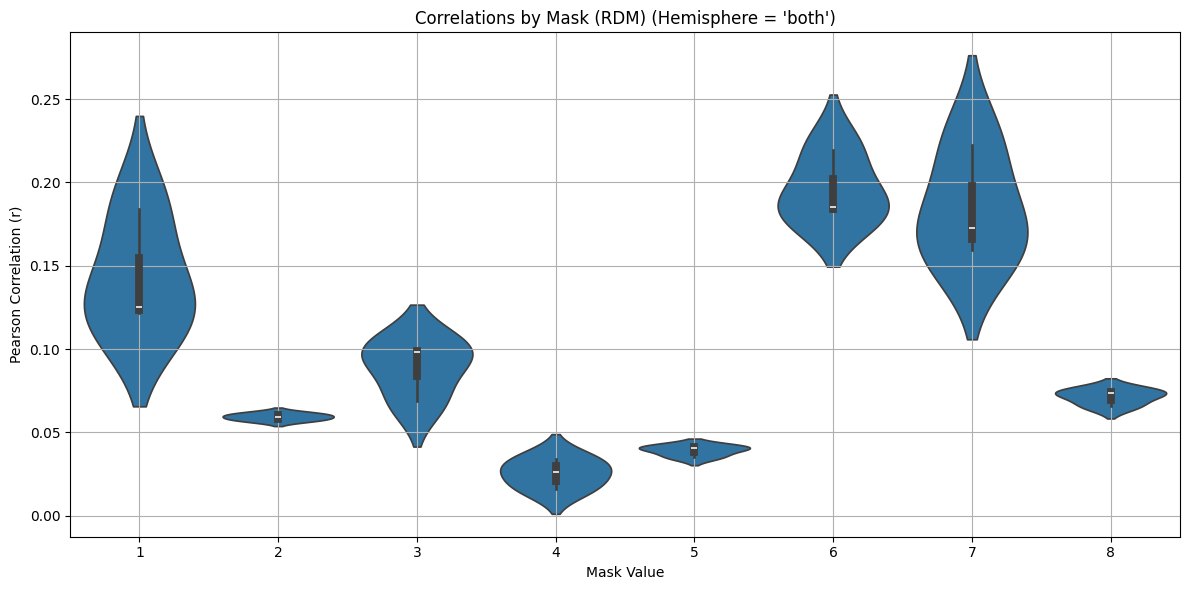

In [27]:
# Visualisierung: Violinplot der rohen Korrelationen pro Maske
import matplotlib.pyplot as plt
import seaborn as sns

# In DataFrame umwandeln
df_corrs = pd.DataFrame(all_correlations_rdm)
print(all_correlations_rdm)

plt.figure(figsize=(12, 6))
sns.violinplot(
    data=df_corrs,
    x="mask_value",
    y="correlation",
    inner="box",
    scale="width"
)
plt.title("Correlations by Mask (RDM) (Hemisphere = 'both')")
plt.xlabel("Mask Value")
plt.ylabel("Pearson Correlation (r)")
plt.grid(True)
plt.tight_layout()
# plt.show()
plt.savefig(os.path.join("..", config.directories.output_dir, "violin_plot_rdm.png"))




Processing dataset: faceclass

Processing subject: 01
  Mask 1 (both)
    Correlation (0 vs 1): r = 0.130
    Correlation (0 vs 2): r = 0.196
    Correlation (1 vs 2): r = 0.126
  Mask 1 (lh)
    Correlation (0 vs 1): r = 0.095
    Correlation (0 vs 2): r = 0.148
    Correlation (1 vs 2): r = 0.101
  Mask 1 (rh)
    Correlation (0 vs 1): r = 0.170
    Correlation (0 vs 2): r = 0.204
    Correlation (1 vs 2): r = 0.148
  Mask 2 (both)
    Correlation (0 vs 1): r = 0.057
    Correlation (0 vs 2): r = 0.062
    Correlation (1 vs 2): r = 0.056
  Mask 2 (lh)
    Correlation (0 vs 1): r = 0.015
    Correlation (0 vs 2): r = 0.018
    Correlation (1 vs 2): r = 0.002
  Mask 2 (rh)
    Correlation (0 vs 1): r = 0.092
    Correlation (0 vs 2): r = 0.105
    Correlation (1 vs 2): r = 0.086
  Mask 3 (both)
    Correlation (0 vs 1): r = 0.060
    Correlation (0 vs 2): r = 0.091
    Correlation (1 vs 2): r = 0.091
  Mask 3 (lh)
    Correlation (0 vs 1): r = 0.047
    Correlation (0 vs 2): r = 0.058

    Correlation (0 vs 1): r = 0.161
    Correlation (0 vs 2): r = 0.156
    Correlation (1 vs 2): r = 0.169
  Mask 7 (both)
    Correlation (0 vs 1): r = 0.407
    Correlation (0 vs 2): r = 0.439
    Correlation (1 vs 2): r = 0.404
  Mask 7 (lh)
    Correlation (0 vs 1): r = 0.238
    Correlation (0 vs 2): r = 0.282
    Correlation (1 vs 2): r = 0.217
  Mask 7 (rh)
    Correlation (0 vs 1): r = 0.374
    Correlation (0 vs 2): r = 0.384
    Correlation (1 vs 2): r = 0.367
  Mask 8 (both)
    Not enough samples. Skipping.
  Mask 8 (lh)
    Not enough samples. Skipping.
  Mask 8 (rh)
    Not enough samples. Skipping.
  Mask 9 (both)
    Correlation (0 vs 1): r = 0.026
    Correlation (0 vs 2): r = 0.025
    Correlation (1 vs 2): r = 0.009
  Mask 9 (lh)
    Correlation (0 vs 1): r = 0.033
    Correlation (0 vs 2): r = 0.037
    Correlation (1 vs 2): r = 0.036
  Mask 9 (rh)
    Correlation (0 vs 1): r = 0.030
    Correlation (0 vs 2): r = 0.016
    Correlation (1 vs 2): r = 0.000

Processin

    Not enough samples. Skipping.
  Mask 9 (both)
    Correlation (0 vs 1): r = -0.004
  Mask 9 (lh)
    Correlation (0 vs 1): r = 0.006
  Mask 9 (rh)
    Correlation (0 vs 1): r = -0.003

Processing subject: 05
  Mask 1 (both)
    Correlation (0 vs 1): r = 0.237
    Correlation (0 vs 2): r = 0.204
    Correlation (1 vs 2): r = 0.251
  Mask 1 (lh)
    Correlation (0 vs 1): r = 0.164
    Correlation (0 vs 2): r = 0.167
    Correlation (1 vs 2): r = 0.200
  Mask 1 (rh)
    Correlation (0 vs 1): r = 0.252
    Correlation (0 vs 2): r = 0.193
    Correlation (1 vs 2): r = 0.243
  Mask 2 (both)
    Correlation (0 vs 1): r = 0.010
    Correlation (0 vs 2): r = 0.010
    Correlation (1 vs 2): r = 0.018
  Mask 2 (lh)
    Correlation (0 vs 1): r = -0.002
    Correlation (0 vs 2): r = 0.005
    Correlation (1 vs 2): r = -0.020
  Mask 2 (rh)
    Correlation (0 vs 1): r = 0.028
    Correlation (0 vs 2): r = 0.008
    Correlation (1 vs 2): r = 0.023
  Mask 3 (both)
    Correlation (0 vs 1): r = 0.01

    Correlation (0 vs 2): r = 0.005
    Correlation (1 vs 2): r = 0.026
  Mask 5 (both)
    Correlation (0 vs 1): r = 0.012
    Correlation (0 vs 2): r = 0.029
    Correlation (1 vs 2): r = 0.015
  Mask 5 (lh)
    Correlation (0 vs 1): r = 0.022
    Correlation (0 vs 2): r = -0.002
    Correlation (1 vs 2): r = 0.013
  Mask 5 (rh)
    Correlation (0 vs 1): r = 0.014
    Correlation (0 vs 2): r = 0.025
    Correlation (1 vs 2): r = 0.022
  Mask 6 (both)
    Correlation (0 vs 1): r = 0.191
    Correlation (0 vs 2): r = 0.173
    Correlation (1 vs 2): r = 0.145
  Mask 6 (lh)
    Correlation (0 vs 1): r = 0.204
    Correlation (0 vs 2): r = 0.191
    Correlation (1 vs 2): r = 0.167
  Mask 6 (rh)
    Correlation (0 vs 1): r = 0.130
    Correlation (0 vs 2): r = 0.121
    Correlation (1 vs 2): r = 0.091
  Mask 7 (both)
    Correlation (0 vs 1): r = 0.217
    Correlation (0 vs 2): r = 0.152
    Correlation (1 vs 2): r = 0.198
  Mask 7 (lh)
    Correlation (0 vs 1): r = 0.264
    Correlation (

/tmp/ipykernel_74523/3516274595.py:120: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


    Correlation (0 vs 2): r = -0.010
    Correlation (1 vs 2): r = 0.015
  Mask 3 (rh)
    Correlation (0 vs 1): r = -0.004
    Correlation (0 vs 2): r = 0.006
    Correlation (1 vs 2): r = -0.002
  Mask 4 (both)
    Not enough samples. Skipping.
  Mask 4 (lh)
    Not enough samples. Skipping.
  Mask 4 (rh)
    Not enough samples. Skipping.
  Mask 5 (both)
    Correlation (0 vs 1): r = 0.020
    Correlation (0 vs 2): r = 0.012
    Correlation (1 vs 2): r = 0.009
  Mask 5 (lh)
    Correlation (0 vs 1): r = 0.032
    Correlation (0 vs 2): r = 0.003
    Correlation (1 vs 2): r = 0.016
  Mask 5 (rh)
    Correlation (0 vs 1): r = -0.014
    Correlation (0 vs 2): r = 0.014
    Correlation (1 vs 2): r = 0.009
  Mask 6 (both)
    Not enough samples. Skipping.
  Mask 6 (lh)
    Not enough samples. Skipping.
  Mask 6 (rh)
    Not enough samples. Skipping.
  Mask 7 (both)
    Correlation (0 vs 1): r = 0.136
    Correlation (0 vs 2): r = 0.081
    Correlation (1 vs 2): r = 0.122
  Mask 7 (lh)
    

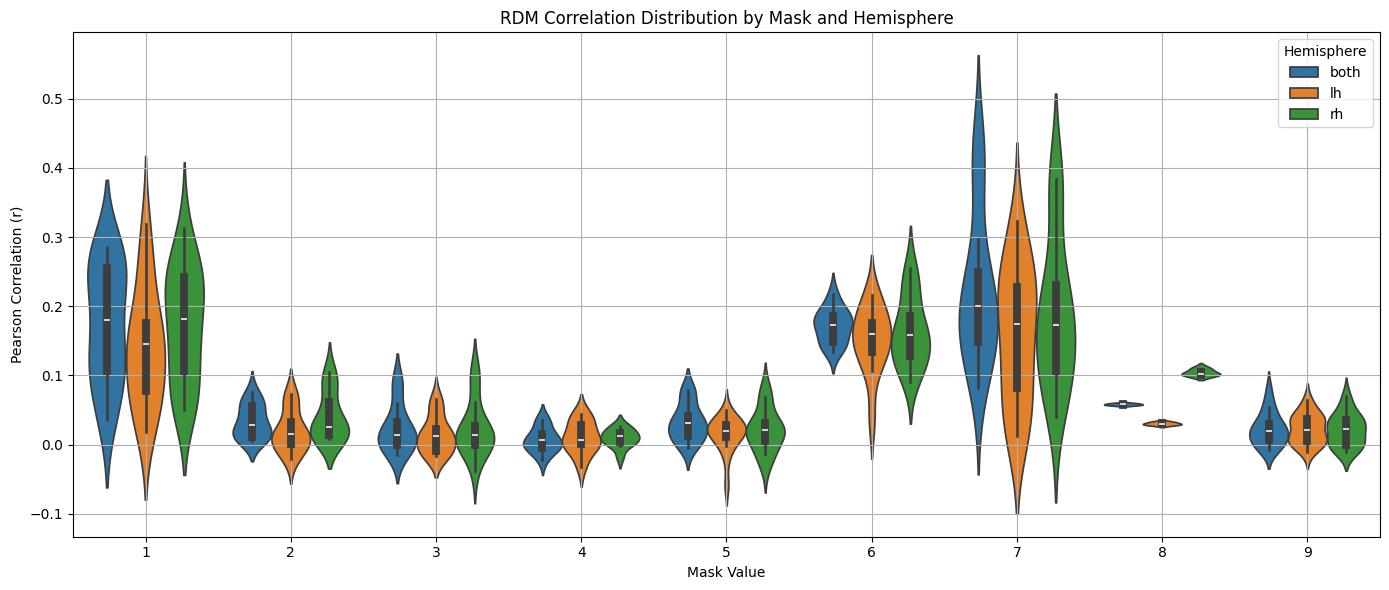

In [7]:
import sys
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr, kendalltau
import pandas as pd
import logging

# Append the repository root to sys.path to load our configuration utilities
sys.path.append(os.path.abspath(".."))
from utils.config import load_config, Configuration

# Load the configuration from the YAML file
config = load_config("../config.yaml")

# Define experimental parameters
sets = ["faceclass"]  # Replace with actual set name(s)
subjects = range(1, 9)  # Subjects 1 through 8
mode = "single"
hemispheres = ["both", "lh", "rh"]
samples_to_compare = [0, 1, 2]

# Define correlation method
def compare_rdms(rdm1, rdm2, method='pearson'):
    if method == 'pearson':
        return pearsonr(rdm1, rdm2)
    elif method == 'spearman':
        return spearmanr(rdm1, rdm2)
    else:
        return kendalltau(rdm1, rdm2)

# Optionally: Visualization (disabled here)
def visualize_rdm_comparison(rdm1, rdm2, rdm_1_str, rdm_2_str, correlation, mask_value):
    square_rdm1 = squareform(rdm1)
    square_rdm2 = squareform(rdm2)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(square_rdm1, ax=ax1, cmap='viridis')
    ax1.set_title(f'{rdm_1_str} - Mask: {mask_value}')

    sns.heatmap(square_rdm2, ax=ax2, cmap='viridis')
    ax2.set_title(f'{rdm_2_str} - Mask: {mask_value}')
    display.display(plt.gcf())
    plt.close()

    plt.figure(figsize=(6, 6))
    plt.scatter(rdm1, rdm2, alpha=0.5, s=1)
    plt.xlabel(f'{rdm_1_str}')
    plt.ylabel(f'{rdm_2_str}')
    plt.title(f'Correlation: {correlation:.2f} (Mask: {mask_value})')
    display.display(plt.gcf())
    plt.close()

# Collect correlation results
all_correlations_rdm = []

# Main loop
for set_path in sets:
    print(f"\nProcessing dataset: {set_path}")
    time.sleep(1)

    # Set RDM directory
    config.directories.rdm_dir = f"data/rdm/rdm_{set_path}"

    for subj in subjects:
        print(f"\nProcessing subject: {subj:02d}")
        for mask_value in range(1, 10):
            for hemi in hemispheres:
                print(f"  Mask {mask_value} ({hemi})")
                sample_rdms = {}

                for sample in samples_to_compare:
                    rdm_path = os.path.join(
                        "..",
                        config.directories.rdm_dir,
                        f"subj_{subj:02d}",
                        f"subj_{subj:02d}",
                        f"mask_{mask_value}_{mode}_sample_{sample}_{hemi}_rdm.npy"
                    )
                    if os.path.exists(rdm_path):
                        try:
                            sample_rdms[sample] = np.load(rdm_path)
                            logging.info(f"Loaded RDM: {rdm_path}")
                        except Exception as e:
                            logging.warning(f"Error loading RDM: {e}")
                    else:
                        logging.warning(f"Missing RDM: {rdm_path}")

                if len(sample_rdms) < 2:
                    print(f"    Not enough samples. Skipping.")
                    continue

                sample_indices = sorted(sample_rdms.keys())
                rdm_samples = [sample_rdms[i] for i in sample_indices]

                for i in range(len(rdm_samples)):
                    for j in range(i + 1, len(rdm_samples)):
                        try:
                            corr, _ = compare_rdms(rdm_samples[i], rdm_samples[j])
                            all_correlations_rdm.append({
                                "subject": subj,
                                "mask_value": mask_value,
                                "hemisphere": hemi,
                                "sample_pair": f"{sample_indices[i]}-{sample_indices[j]}",
                                "correlation": corr
                            })
                            print(f"    Correlation ({sample_indices[i]} vs {sample_indices[j]}): r = {corr:.3f}")
                        except Exception as e:
                            logging.warning(f"Error comparing samples: {e}")

# Convert to DataFrame
df_corrs = pd.DataFrame(all_correlations_rdm)

# Plot grouped violin plots
plt.figure(figsize=(14, 6))
sns.violinplot(
    data=df_corrs,
    x="mask_value",
    y="correlation",
    hue="hemisphere",
    inner="box",
    scale="width"
)
plt.title("RDM Correlation Distribution by Mask and Hemisphere")
plt.xlabel("Mask Value")
plt.ylabel("Pearson Correlation (r)")
plt.legend(title="Hemisphere")
plt.grid(True)
plt.tight_layout()

# Save
output_path = os.path.join("..", config.directories.output_dir, "violin_plot_rdm_by_hemi.png")
plt.savefig(output_path)
print(f"Saved violin plot to {output_path}")


In [8]:
all_correlations_rdm

[{'subject': 1,
  'mask_value': 1,
  'hemisphere': 'both',
  'sample_pair': '0-1',
  'correlation': 0.1303648430095135},
 {'subject': 1,
  'mask_value': 1,
  'hemisphere': 'both',
  'sample_pair': '0-2',
  'correlation': 0.19614564087259112},
 {'subject': 1,
  'mask_value': 1,
  'hemisphere': 'both',
  'sample_pair': '1-2',
  'correlation': 0.12575508951593456},
 {'subject': 1,
  'mask_value': 1,
  'hemisphere': 'lh',
  'sample_pair': '0-1',
  'correlation': 0.09516968244632391},
 {'subject': 1,
  'mask_value': 1,
  'hemisphere': 'lh',
  'sample_pair': '0-2',
  'correlation': 0.1480686310201597},
 {'subject': 1,
  'mask_value': 1,
  'hemisphere': 'lh',
  'sample_pair': '1-2',
  'correlation': 0.10050377978807642},
 {'subject': 1,
  'mask_value': 1,
  'hemisphere': 'rh',
  'sample_pair': '0-1',
  'correlation': 0.1697444417456011},
 {'subject': 1,
  'mask_value': 1,
  'hemisphere': 'rh',
  'sample_pair': '0-2',
  'correlation': 0.20428846908503556},
 {'subject': 1,
  'mask_value': 1,
  

In [2]:
import os
import sys
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import display
from scipy.spatial.distance import pdist, squareform
from scipy.stats import pearsonr, spearmanr, kendalltau

# Append the repository root to sys.path to load our configuration utilities
sys.path.append(os.path.abspath(".."))
from utils.config import load_config, Configuration

# Load the configuration from the YAML file
config = load_config("../config.yaml")

# Define our experimental parameters
sets = ["stan_data"]
subj = 2
mode = "single"

# Define helper functions to compare and visualize RDMs
def compare_rdms(rdm1, rdm2, method='pearson'):
    """
    Compare two sets of observations using RDM correlation.

    Parameters:
        rdm1, rdm2 : numpy.ndarray
            Condensed distance matrices.
        method : str
            Correlation method ('pearson', 'spearman', or 'kendall').
            
    Returns:
        tuple : (correlation, p_value, rdm1, rdm2)
    """
    # Calculate correlation based on chosen method.
    if method == 'pearson':
        corr, p_value = pearsonr(rdm1, rdm2)
    elif method == 'spearman':
        corr, p_value = spearmanr(rdm1, rdm2)
    else:  # kendall
        corr, p_value = kendalltau(rdm1, rdm2)
        
    return corr, p_value, rdm1, rdm2

def visualize_rdm_comparison(rdm1, rdm2, rdm_1_str: str, rdm_2_str: str, correlation: float, mask_value: int):
    """
    Create visualization to compare two RDMs.

    Parameters:
        rdm1, rdm2 : numpy.ndarray
            Condensed distance matrices from pdist.
        rdm_1_str : str
            Label for the first RDM.
        rdm_2_str : str
            Label for the second RDM.
        correlation : float
            Correlation value between the two RDMs.
        mask_value : int
            The mask value being visualized.
    """
    # Convert from condensed to square form for visual display.
    square_rdm1 = squareform(rdm1)
    square_rdm2 = squareform(rdm2)

    # Create a figure with two side-by-side subplots for each RDM.
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    sns.heatmap(square_rdm1, ax=ax1, cmap='viridis')
    ax1.set_title(f'{rdm_1_str} - Observation (Mask: {mask_value})')
    
    sns.heatmap(square_rdm2, ax=ax2, cmap='viridis')
    ax2.set_title(f'{rdm_2_str} - Observation (Mask: {mask_value})')
    display.display(plt.gcf())
    plt.close()

    # Create a scatter plot to show the relationship between the two RDM values.
    plt.figure(figsize=(6, 6))
    plt.scatter(rdm1, rdm2, alpha=0.5, s=1)
    plt.xlabel(f'{rdm_1_str} distances')
    plt.ylabel(f'{rdm_2_str} distances')
    plt.title(f'RDM Distance Correlation {correlation:.2f} - (Mask: {mask_value})')
    display.display(plt.gcf())
    plt.close()

# Loop over each data set (e.g., "stan_data")
for set_path in sets:
    print(f"Computing for {set_path} ...")
    time.sleep(1)
    # Update configuration directories for the current set
    config.directories.rdm_dir = f"data/rdm_dir_{set_path}"
    config.directories.mds_dir = f"data/mds_dir_{set_path}"  # although not used in this cell
    
    # Loop over all possible mask values 1 to 8.
    for mask_value in range(1, 9):
        print(f"Processing mask_value = {mask_value}")
        
        # Construct file paths for RDM samples
        rdm_1_path = os.path.join("..", config.directories.rdm_dir,
                                    f"subj_{subj:02d}", f"subj_{subj:02d}",
                                    f"mask_{mask_value}_{mode}_sample_{0}_rdm.npy")
        rdm_2_path = os.path.join("..", config.directories.rdm_dir,
                                    f"subj_{subj:02d}", f"subj_{subj:02d}",
                                    f"mask_{mask_value}_{mode}_sample_{1}_rdm.npy")
        rdm_3_path = os.path.join("..", config.directories.rdm_dir,
                                    f"subj_{subj:02d}", f"subj_{subj:02d}",
                                    f"mask_{mask_value}_{mode}_sample_{2}_rdm.npy")
        
        # Check that at least the first two RDM samples exist.
        if not os.path.exists(rdm_1_path) or not os.path.exists(rdm_2_path):
            print(f"Mask {mask_value}: Required RDM sample files not found. Skipping.")
            continue
        
        # Load sample 0 and sample 1
        try:
            rdm_sample0 = np.load(rdm_1_path)
            rdm_sample1 = np.load(rdm_2_path)
        except Exception as e:
            print(f"Error loading RDM files for mask {mask_value}: {e}")
            continue
        
        # Create a list of available RDM samples and their respective labels.
        rdm_samples = [rdm_sample0, rdm_sample1]
        sample_names = ["RDM 1", "RDM 2"]
        
        # Check for the third sample; load it if available.
        if os.path.exists(rdm_3_path):
            try:
                rdm_sample2 = np.load(rdm_3_path)
                rdm_samples.append(rdm_sample2)
                sample_names.append("RDM 3")
            except Exception as e:
                print(f"Error loading RDM sample 3 for mask {mask_value}: {e}")
        
        # Ensure that we have at least two samples.
        n_samples = len(rdm_samples)
        if n_samples < 2:
            print(f"Mask {mask_value}: Not enough RDM samples for comparison. Skipping.")
            continue
        
        # Always compare sample 0 vs sample 1.
        corr, p_value, rdm1_val, rdm2_val = compare_rdms(rdm_samples[0], rdm_samples[1])
        visualize_rdm_comparison(rdm1_val, rdm2_val, sample_names[0], sample_names[1], corr, mask_value)
        
        # If the third sample exists, perform an additional comparison between sample 0 and sample 2.
        if n_samples >= 3:
            corr, p_value, rdm1_val, rdm3_val = compare_rdms(rdm_samples[0], rdm_samples[2])
            visualize_rdm_comparison(rdm1_val, rdm3_val, sample_names[0], sample_names[2], corr, mask_value)


Computing for stan_data ...
Processing mask_value = 1
Mask 1: Required RDM sample files not found. Skipping.
Processing mask_value = 2
Mask 2: Required RDM sample files not found. Skipping.
Processing mask_value = 3
Mask 3: Required RDM sample files not found. Skipping.
Processing mask_value = 4
Mask 4: Required RDM sample files not found. Skipping.
Processing mask_value = 5
Mask 5: Required RDM sample files not found. Skipping.
Processing mask_value = 6
Mask 6: Required RDM sample files not found. Skipping.
Processing mask_value = 7
Mask 7: Required RDM sample files not found. Skipping.
Processing mask_value = 8
Mask 8: Required RDM sample files not found. Skipping.
